In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import negative_sampling
from torch_geometric.nn.conv.gcn_conv import gcn_norm
import networkx as nx
from itertools import combinations
from tqdm.auto import tqdm
import re
import warnings
warnings.filterwarnings('ignore')

C:\Users\Simone\anaconda3\envs\pyg_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import zipfile
import os

zip_path = r"C:\Users\Simone\OneDrive\Desktop\emails.csv.zip"
extract_path = r"C:\Users\Simone\enron"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print(os.listdir(extract_path))

['emails.csv']


In [4]:
df = pd.read_csv(r"C:\Users\Simone\enron\emails.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst row:\n", df.iloc[0])

Shape: (517401, 2)

Columns: ['file', 'message']

First row:
 file                                   allen-p/_sent_mail/1.
message    Message-ID: <18782981.1075855378110.JavaMail.e...
Name: 0, dtype: object


In [5]:
df = pd.read_csv(r"C:\Users\Simone\enron\emails.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())
print("\nSample row:\n", df.iloc[0])
print("\nFirst 5 rows:\n", df.head())

Shape: (517401, 2)

Columns: ['file', 'message']

Dtypes:
 file       object
message    object
dtype: object

Null counts:
 file       0
message    0
dtype: int64

Sample row:
 file                                   allen-p/_sent_mail/1.
message    Message-ID: <18782981.1075855378110.JavaMail.e...
Name: 0, dtype: object

First 5 rows:
                        file                                            message
0     allen-p/_sent_mail/1.  Message-ID: <18782981.1075855378110.JavaMail.e...
1    allen-p/_sent_mail/10.  Message-ID: <15464986.1075855378456.JavaMail.e...
2   allen-p/_sent_mail/100.  Message-ID: <24216240.1075855687451.JavaMail.e...
3  allen-p/_sent_mail/1000.  Message-ID: <13505866.1075863688222.JavaMail.e...
4  allen-p/_sent_mail/1001.  Message-ID: <30922949.1075863688243.JavaMail.e...


In [6]:
def parse_field(message, field):
    match = re.search(rf'^{field}:\s*(.+)', message, re.MULTILINE)
    return match.group(1).strip() if match else None

df['from'] = df['message'].apply(lambda x: parse_field(x, 'From'))
df['to']   = df['message'].apply(lambda x: parse_field(x, 'To'))
df['date'] = df['message'].apply(lambda x: parse_field(x, 'Date'))
df['subject'] = df['message'].apply(lambda x: parse_field(x, 'Subject'))

print(df[['from','to','date','subject']].head(10))
print("\nNull from:", df['from'].isnull().sum())
print("Null to:  ", df['to'].isnull().sum())

                      from                                                to  \
0  phillip.allen@enron.com                              tim.belden@enron.com   
1  phillip.allen@enron.com                           john.lavorato@enron.com   
2  phillip.allen@enron.com                            leah.arsdall@enron.com   
3  phillip.allen@enron.com                             randall.gay@enron.com   
4  phillip.allen@enron.com                              greg.piper@enron.com   
5  phillip.allen@enron.com                              greg.piper@enron.com   
6  phillip.allen@enron.com  david.l.johnson@enron.com, john.shafer@enron.com   
7  phillip.allen@enron.com                          joyce.teixeira@enron.com   
8  phillip.allen@enron.com                              mark.scott@enron.com   
9  phillip.allen@enron.com                                   zimam@enron.com   

                                    date  \
0  Mon, 14 May 2001 16:39:00 -0700 (PDT)   
1   Fri, 4 May 2001 13:51:00 -0

In [7]:
def clean_email(addr):
    if not isinstance(addr, str):
        return None
    addr = addr.strip().lower()
    addr = re.sub(r'\s+', '', addr)
    if '@' not in addr:
        return None
    return addr

df = df.dropna(subset=['from', 'to'])

df['from'] = df['from'].apply(clean_email)

df['to'] = df['to'].apply(lambda x: [
    clean_email(e) for e in re.split(r'[,;]', x)
    if clean_email(e) is not None
])

df = df[df['from'].notna()]
df = df[df['to'].map(len) > 0]

df_exploded = df.explode('to').reset_index(drop=True)
df_exploded = df_exploded[df_exploded['from'] != df_exploded['to']]
df_exploded = df_exploded.dropna(subset=['from', 'to'])

print("Total edges (raw):", len(df_exploded))
print("Unique senders:  ", df_exploded['from'].nunique())
print("Unique receivers:", df_exploded['to'].nunique())
print(df_exploded[['from','to']].head(10))

Total edges (raw): 713665
Unique senders:   19447
Unique receivers: 26063
                      from                         to
0  phillip.allen@enron.com       tim.belden@enron.com
1  phillip.allen@enron.com    john.lavorato@enron.com
2  phillip.allen@enron.com     leah.arsdall@enron.com
3  phillip.allen@enron.com      randall.gay@enron.com
4  phillip.allen@enron.com       greg.piper@enron.com
5  phillip.allen@enron.com       greg.piper@enron.com
6  phillip.allen@enron.com  david.l.johnson@enron.com
7  phillip.allen@enron.com      john.shafer@enron.com
8  phillip.allen@enron.com   joyce.teixeira@enron.com
9  phillip.allen@enron.com       mark.scott@enron.com


In [8]:
edge_counts = df_exploded.groupby(['from','to']).size().reset_index(name='weight')
edge_counts = edge_counts[edge_counts['weight'] >= 1]

all_users = pd.unique(edge_counts[['from','to']].values.ravel())
user2idx  = {u: i for i, u in enumerate(all_users)}
idx2user  = {i: u for u, i in user2idx.items()}
num_users = len(all_users)

print("Unique users in graph:", num_users)
print("Edges after weight filter:", len(edge_counts))
print(edge_counts.head())

src = torch.tensor([user2idx[u] for u in edge_counts['from']], dtype=torch.long)
dst = torch.tensor([user2idx[u] for u in edge_counts['to']],   dtype=torch.long)

edge_index = torch.stack([
    torch.cat([src, dst]),
    torch.cat([dst, src])
], dim=0)

print("\nedge_index shape:", edge_index.shape)

Unique users in graph: 36613
Edges after weight filter: 104339
                             from                      to  weight
0   'todd'.delahoussaye@enron.com  derek.bailey@enron.com       5
1   'todd'.delahoussaye@enron.com     jean.bell@enron.com       5
2   'todd'.delahoussaye@enron.com  randy.bhatia@enron.com       5
3   'todd'.delahoussaye@enron.com  susan.bailey@enron.com       1
4  --migrated--bmishkin@ercot.com    mockmarket@ercot.com       1

edge_index shape: torch.Size([2, 208678])


In [9]:
num_edges = edge_index.shape[1] // 2
perm = torch.randperm(num_edges)

train_end = int(0.8 * num_edges)
val_end   = int(0.9 * num_edges)

train_idx = perm[:train_end]
val_idx   = perm[train_end:val_end]
test_idx  = perm[val_end:]

def make_bidirectional(idx):
    s = torch.cat([src[idx], dst[idx]])
    d = torch.cat([dst[idx], src[idx]])
    return torch.stack([s, d])

train_edge_index = make_bidirectional(train_idx)
val_edge_index   = make_bidirectional(val_idx)
test_edge_index  = make_bidirectional(test_idx)

print("Train edges:", train_edge_index.shape)
print("Val edges:  ", val_edge_index.shape)
print("Test edges: ", test_edge_index.shape)

Train edges: torch.Size([2, 166942])
Val edges:   torch.Size([2, 20868])
Test edges:  torch.Size([2, 20868])


In [10]:
class FriendGNN(MessagePassing):
    def __init__(self, num_users, embedding_dim=64, K=3, add_self_loops=False):
        super().__init__()
        self.num_users      = num_users
        self.embedding_dim  = embedding_dim
        self.K              = K
        self.add_self_loops = add_self_loops

        self.emb = nn.Embedding(num_users, embedding_dim)
        nn.init.normal_(self.emb.weight, std=0.1)

    def forward(self, edge_index: Tensor):
        edge_index_norm = gcn_norm(
            edge_index,
            num_nodes=self.num_users,
            add_self_loops=self.add_self_loops
        )
        emb_0 = self.emb.weight
        embs  = [emb_0]
        emb_k = emb_0

        for _ in range(self.K):
            emb_k = self.propagate(
                edge_index=edge_index_norm[0],
                x=emb_k,
                norm=edge_index_norm[1]
            )
            embs.append(emb_k)

        emb_final = torch.mean(torch.stack(embs, dim=1), dim=1)
        return emb_final, emb_0

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

In [11]:
def bpr_loss(emb_final, emb_0, pos_src, pos_dst, neg_dst, lambda_val=1e-4):
    u   = emb_final[pos_src]
    pos = emb_final[pos_dst]
    neg = emb_final[neg_dst]

    pos_scores = (u * pos).sum(dim=-1)
    neg_scores = (u * neg).sum(dim=-1)

    bpr  = -torch.mean(torch.nn.functional.softplus(pos_scores - neg_scores))
    reg  = lambda_val * (
        emb_0[pos_src].norm(2).pow(2) +
        emb_0[pos_dst].norm(2).pow(2) +
        emb_0[neg_dst].norm(2).pow(2)
    )
    return bpr + reg

In [18]:
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ITERATIONS = 10000
LR         = 1e-3
LAMBDA     = 1e-4
BATCH_SIZE = 1024
ITERS_PER_EVAL = 500

model     = FriendGNN(num_users=num_users).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

train_ei = train_edge_index.to(device)
train_losses = []

for iter in tqdm(range(ITERATIONS), mininterval=1.0):
    model.train()
    emb_final, emb_0 = model.forward(train_ei)

    idx     = torch.randint(0, train_ei.shape[1] // 2, (BATCH_SIZE,))
    pos_src = train_ei[0][idx]
    pos_dst = train_ei[1][idx]
    neg_dst = torch.randint(0, num_users, (BATCH_SIZE,), device=device)

    loss = bpr_loss(emb_final, emb_0, pos_src, pos_dst, neg_dst, LAMBDA)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if iter % ITERS_PER_EVAL == 0:
        print(f"[{iter}/{ITERATIONS}] loss: {round(loss.item(), 5)}")

    if iter % 2000 == 0 and iter != 0:
        scheduler.step()

  0%|                                                                                        | 0/10000 [00:00<?, ?it/s]

[0/10000] loss: -0.50876


  5%|███▉                                                                          | 501/10000 [01:57<37:45,  4.19it/s]

[500/10000] loss: -41.39993


 10%|███████▊                                                                      | 997/10000 [03:56<35:00,  4.29it/s]

...

 90%|█████████████████████████████████████████████████████████████████████▎       | 8999/10000 [30:39<03:18,  5.04it/s]

[9000/10000] loss: -7522.97168


 95%|█████████████████████████████████████████████████████████████████████████▏   | 9501/10000 [32:19<01:39,  5.00it/s]

[9500/10000] loss: -8254.98047


100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [33:59<00:00,  4.90it/s]


In [19]:
model.eval()
with torch.no_grad():
    emb_final, _ = model.forward(train_ei)

def recommend_friends(user_email, top_k=10):
    if user_email not in user2idx:
        print("User not found.")
        return

    uid = user2idx[user_email]

    existing = set(
        edge_index[1][edge_index[0] == uid].tolist()
    )
    existing.add(uid)

    scores = (emb_final[uid] * emb_final).sum(dim=-1)
    scores[list(existing)] = -1e9

    top_scores, top_ids = torch.topk(scores, top_k)
    top_scores = torch.sigmoid(top_scores)

    print(f"\nTop {top_k} recommendations for: {user_email}\n")
    print(f"{'User':<40} {'Score':>8}")
    print("-" * 50)
    for idx, score in zip(top_ids.tolist(), top_scores.tolist()):
        print(f"{idx2user[idx]:<40} {score:>8.4f}")

recommend_friends(idx2user[0])


Top 10 recommendations for: 'todd'.delahoussaye@enron.com

User                                        Score
--------------------------------------------------
sara.shackleton@enron.com                  1.0000
tana.jones@enron.com                       1.0000
vince.kaminski@enron.com                   1.0000
jeff.dasovich@enron.com                    1.0000
jeff.skilling@enron.com                    1.0000
gerald.nemec@enron.com                     1.0000
kenneth.lay@enron.com                      1.0000
mark.taylor@enron.com                      1.0000
kay.mann@enron.com                         1.0000
sally.beck@enron.com                       1.0000


In [20]:
recommend_friends('phillip.allen@enron.com')


Top 10 recommendations for: phillip.allen@enron.com

User                                        Score
--------------------------------------------------
sara.shackleton@enron.com                  1.0000
tana.jones@enron.com                       1.0000
vince.kaminski@enron.com                   1.0000
jeff.skilling@enron.com                    1.0000
gerald.nemec@enron.com                     1.0000
kenneth.lay@enron.com                      1.0000
kay.mann@enron.com                         1.0000
debra.perlingiere@enron.com                1.0000
chris.germany@enron.com                    1.0000
louise.kitchen@enron.com                   1.0000


In [21]:
G = nx.Graph()
edges_list = list(zip(src.tolist(), dst.tolist()))
G.add_edges_from(edges_list)

def get_clique_suggestions(user_email, top_k=5):
    if user_email not in user2idx:
        print("User not found.")
        return

    uid = user2idx[user_email]

    components = [c for c in nx.connected_components(G) if uid in c]
    if not components:
        print("User has no connections.")
        return

    component = G.subgraph(components[0])
    cliques   = list(nx.find_cliques(component))
    user_cliques = [c for c in cliques if uid in c]

    print(f"\nUser: {user_email}")
    print(f"Is in {len(user_cliques)} clique(s)\n")

    non_edges = []
    for node in component.nodes():
        if node != uid and not G.has_edge(uid, node):
            mutual = len(list(nx.common_neighbors(G, uid, node)))
            score  = mutual / (G.degree(uid) + G.degree(node) - mutual + 1e-9)
            non_edges.append((node, mutual, round(score, 4)))

    non_edges.sort(key=lambda x: x[2], reverse=True)

    print(f"Top {top_k} users to connect with (would expand clique):\n")
    print(f"{'User':<40} {'Mutuals':>8} {'Score':>8}")
    print("-" * 58)
    for node, mutual, score in non_edges[:top_k]:
        print(f"{idx2user[node]:<40} {mutual:>8} {score:>8.4f}")

    max_clique = max(user_cliques, key=len) if user_cliques else []
    missing    = [
        (u, v) for u, v in combinations(max_clique, 2)
        if not G.has_edge(u, v)
    ]
    if missing:
        print(f"\nMissing edges to complete maximal clique {[idx2user[n] for n in max_clique]}:")
        for u, v in missing:
            print(f"  {idx2user[u]} <-> {idx2user[v]}")
    else:
        print(f"\nUser's largest clique is already maximal ({len(max_clique)} nodes).")

get_clique_suggestions(idx2user[0])


User: 'todd'.delahoussaye@enron.com
Is in 4 clique(s)

Top 5 users to connect with (would expand clique):

User                                      Mutuals    Score
----------------------------------------------------------
julie.brewer@enron.com                          2   0.2500
admin@iwin.com                                  1   0.2000
brooksbrothers@clickaction.net                  1   0.2000
cptdougie@aol.com                               1   0.2000
dona.carmony@ourclub.com                        1   0.2000

User's largest clique is already maximal (3 nodes).


In [22]:
recommend_friends('phillip.allen@enron.com')
get_clique_suggestions('phillip.allen@enron.com')


Top 10 recommendations for: phillip.allen@enron.com

User                                        Score
--------------------------------------------------
sara.shackleton@enron.com                  1.0000
tana.jones@enron.com                       1.0000
vince.kaminski@enron.com                   1.0000
jeff.skilling@enron.com                    1.0000
gerald.nemec@enron.com                     1.0000
kenneth.lay@enron.com                      1.0000
kay.mann@enron.com                         1.0000
debra.perlingiere@enron.com                1.0000
chris.germany@enron.com                    1.0000
louise.kitchen@enron.com                   1.0000

User: phillip.allen@enron.com
Is in 538 clique(s)

Top 5 users to connect with (would expand clique):

User                                      Mutuals    Score
----------------------------------------------------------
k..allen@enron.com                             50   0.1420
s..shively@enron.com                           26   0.0732
david

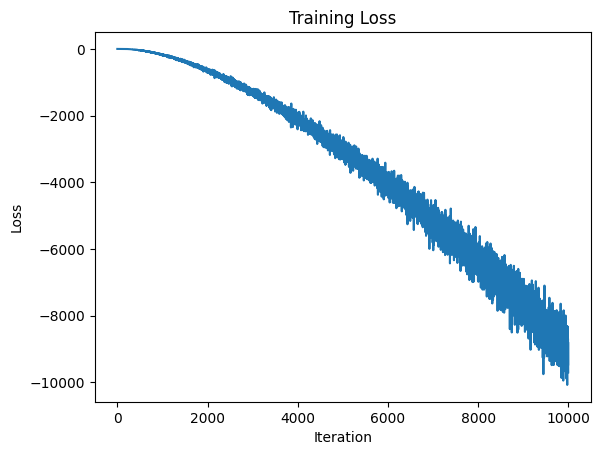

In [23]:
import matplotlib.pyplot as plt
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()